# 02 · The pass he didn't see: expected value of every passing option

For every open-play pass with a freeze frame and an identified intended target, and for **every visible
teammate j**:

    EV_j = P(complete to j) * V(our ball at j) + (1 - P) * V(their ball near j)

Two value definitions are compared:
* **goal10:** P(score within 10 actions) − P(concede within 10 actions) (VAEP-style)
* **poss:** xG of the rest of our possession − xG of the opponent's next possession

Plus a **pass-selection model** (what a typical professional would choose), used to keep
recommendations to *plausible* options.

All per-pass numbers come from 4-fold match-grouped **out-of-fold** scoring (`scripts/score_passes.py`).
Component metrics in §1 are on the held-out Euro 2024 test set.

In [1]:
import json, numpy as np, pandas as pd, matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display, Markdown
from sklearn.metrics import roc_auc_score
from scipy.stats import spearmanr
from phds.data.freeze_frames import PROCESSED_DIR, load_table
from phds.eval.metrics import fmt_ci, cluster_bootstrap, mean_ci
from phds.viz.pitch import plot_freeze_frame

pd.set_option("display.width", 170); pd.set_option("display.max_columns", 30)
OUT = Path("../reports/m2"); OUT.mkdir(parents=True, exist_ok=True)
dec = pd.read_parquet(PROCESSED_DIR / "pass_decisions.parquet")
opts = pd.read_parquet(PROCESSED_DIR / "pass_options.parquet", columns=["event_id", "player_idx", "opt_x", "opt_y",
    "is_actual", "p_complete", "policy_p", "ev_goal10", "ev_poss", "length", "dx"])
matches = load_table("matches")
matches["comp"] = matches["competition_competition_name"] + " " + matches["season_season_name"]
dec["comp"] = dec["match_id"].map(matches.set_index("match_id")["comp"])
print(f"{len(dec):,} passes, {len(opts):,} options, {dec['player_id'].nunique():,} players; "
      f"median options {dec['n_options'].median():.0f}, median plausible {dec['n_plausible'].median():.0f}")

220,029 passes, 1,512,851 options, 3,126 players; median options 7, median plausible 2


## 1. Component models (Euro 2024 test set, trained on train+val)

In [2]:
load = lambda name: json.loads((OUT / f"{name}.json").read_text())
comp = load("completion_test")
display(Markdown(f"**Completion** ({comp['n_eval']:,} test passes, weighted to passes with a visible recipient)"))
display(pd.DataFrame([{"model": m["model"], "log loss": fmt_ci(m["log_loss"]), "Brier": fmt_ci(m["brier"]),
    "AUC": fmt_ci(m["auc"]), "ECE": round(m["ece"], 4), "mean pred": round(m["mean_pred"], 3),
    "observed": round(m["observed"], 3)} for m in comp["models"]]).set_index("model"))
display(pd.Series({k: fmt_ci(v, digits=4) for k, v in comp["comparisons"].items()}, name="paired difference").to_frame())
val = load("value_test")
display(Markdown(f"**Possession value, goal10** ({val['n_eval']:,} test actions)"))
display(pd.DataFrame([{"model": m["model"], "target": m["target"], "log loss": fmt_ci(m["log_loss"], digits=4),
    "AUC": fmt_ci(m["auc"]), "ECE": round(m["ece"], 4)} for m in val["models"]]).set_index(["model", "target"]))
display(Markdown("**Possession value, poss** (regression; R² vs training mean, decile calibration)"))
display(pd.DataFrame([{"model": m["model"], "R2": fmt_ci(m["r2_vs_mean"], digits=4), "RMSE": round(m["rmse"], 4),
    "lowest decile pred/obs": tuple(round(x, 4) for x in m["decile_calibration"][0]),
    "highest decile pred/obs": tuple(round(x, 4) for x in m["decile_calibration"][-1])} for m in val["possession_value"]]).set_index("model"))
display(pd.Series({k: fmt_ci(v, digits=6) for k, v in val["comparisons"].items()}, name="paired difference").to_frame())

**Completion** (29,323 test passes, weighted to passes with a visible recipient)

,log loss,Brier,AUC,ECE,mean pred,observed
model,,,,,,
distance,"0.349 [0.328, 0.370]","0.101 [0.093, 0.109]","0.649 [0.632, 0.665]",0.0122,0.870,0.88
physics,"0.241 [0.224, 0.259]","0.073 [0.067, 0.079]","0.891 [0.879, 0.903]",0.0108,0.880,0.88
lgbm_raw,"0.220 [0.201, 0.238]","0.066 [0.060, 0.072]","0.913 [0.903, 0.922]",0.0129,0.893,0.88
lgbm,"0.220 [0.203, 0.236]","0.066 [0.061, 0.072]","0.912 [0.903, 0.922]",0.0108,0.880,0.88


,paired difference
log loss: physics - distance,"-0.1075 [-0.1178, -0.0976]"
log loss: lgbm - physics,"-0.0216 [-0.0246, -0.0186]"
log loss: lgbm - lgbm_raw,"0.0002 [-0.0016, 0.0021]"


**Possession value, goal10** (101,661 test actions)

log loss                   AUC     ECE
model target                                                         
loc   scores    0.0407 [0.0354, 0.0474]  0.783 [0.752, 0.808]  0.0031
      concedes  0.0103 [0.0084, 0.0125]  0.787 [0.723, 0.846]  0.0008
ctx   scores    0.0403 [0.0349, 0.0469]  0.793 [0.767, 0.819]  0.0029
      concedes  0.0096 [0.0077, 0.0120]  0.825 [0.761, 0.879]  0.0006

**Possession value, poss** (regression; R² vs training mean, decile calibration)

,R2,RMSE,lowest decile pred/obs,highest decile pred/obs
model,,,,
poss_loc,"0.0385 [0.0215, 0.0536]",0.0824,"(-0.0051, -0.0014)","(0.0454, 0.0376)"
poss_ctx,"0.0549 [0.0382, 0.0726]",0.0816,"(-0.0067, -0.0021)","(0.0449, 0.0409)"


,paired difference
poss_value MSE: ctx - loc,"-0.000116 [-0.000162, -0.000081]"
scores log loss: ctx - loc,"-0.000417 [-0.000836, -0.000085]"
concedes log loss: ctx - loc,"-0.000651 [-0.000896, -0.000354]"


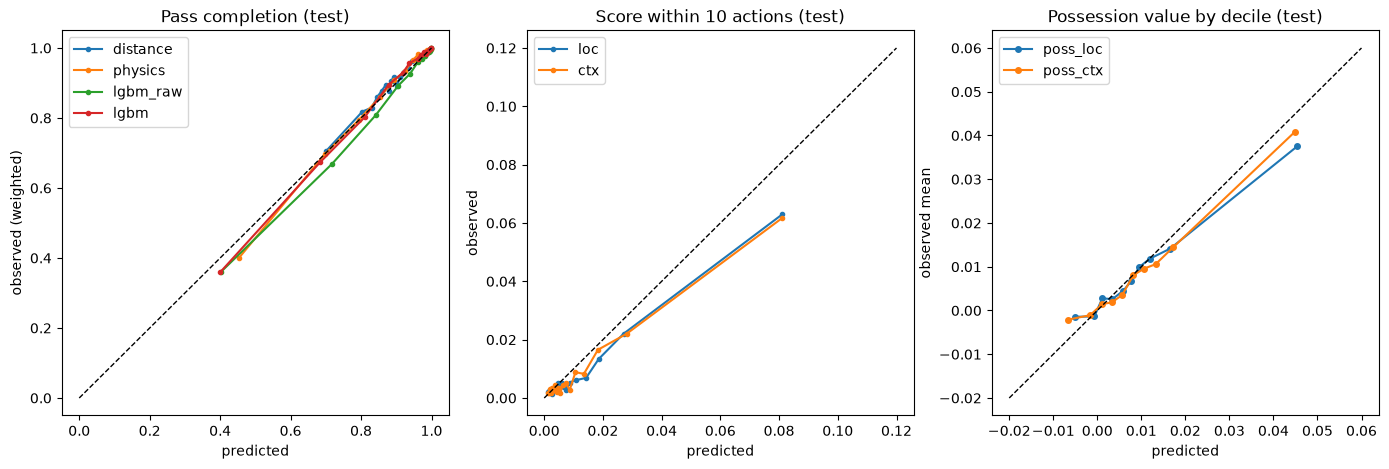

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
for m in comp["models"]:
    rb = np.array(m["reliability"]); axes[0].plot(rb[:, 0], rb[:, 1], "o-", ms=3, label=m["model"])
axes[0].plot([0, 1], [0, 1], "k--", lw=1); axes[0].set(xlabel="predicted", ylabel="observed (weighted)", title="Pass completion (test)"); axes[0].legend()
for m in val["models"]:
    if m["target"] == "scores":
        rb = np.array(m["reliability"]); axes[1].plot(rb[:, 0], rb[:, 1], "o-", ms=3, label=m["model"])
axes[1].plot([0, .12], [0, .12], "k--", lw=1); axes[1].set(xlabel="predicted", ylabel="observed", title="Score within 10 actions (test)"); axes[1].legend()
for m in val["possession_value"]:
    dc = np.array(m["decile_calibration"]); axes[2].plot(dc[:, 0], dc[:, 1], "o-", ms=4, label=m["model"])
lim = [-.02, .06]; axes[2].plot(lim, lim, "k--", lw=1); axes[2].set(xlabel="predicted", ylabel="observed mean", title="Possession value by decile (test)"); axes[2].legend()
fig.savefig(OUT / "component_reliability.png", dpi=140, bbox_inches="tight")

## 2. The diagnostic that reshaped M2
With **goal10**, the "best" option was usually a long forward pass players rarely choose. Players pick
options at the ~78th percentile of completion probability, and EV ranked their choices near random.
Why:
1. **Myopic value:** within 10 actions a turnover in midfield rarely costs a goal, so losing the ball looked almost free.
2. **Selection bias (limitation B):** unplayed forward options are avoided for reasons the frame can't show.

Responses: the **poss** value (turnovers forfeit the rest of the possession and hand over a counter) and
restricting recommendations to **plausible** options (selection model P ≥ 10%).

In [4]:
rows = []
rows.append({"option": "actual (played)", "P(complete)": dec["actual_p_complete"].median(), "length": dec["actual_length"].median(),
             "forward dx": dec["actual_dx"].median(), "policy P": dec["actual_policy_p"].median()})
for v in ["goal10", "poss"]:
    for scope in ["all", "plausible"]:
        pre = f"best_{scope}_{v}_"
        rows.append({"option": f"best by {v}, {scope} options", "P(complete)": dec[pre + "p_complete"].median(),
                     "length": dec[pre + "length"].median(), "forward dx": dec[pre + "dx"].median(),
                     "policy P": dec[pre + "policy_p"].median(),
                     "actual = best": dec[f"actual_is_best_{scope}_{v}"].mean(),
                     "mean choice pct": dec[f"choice_pct_{v}"].mean() if scope == "all" else np.nan})
display(pd.DataFrame(rows).set_index("option").round(3))
print(f"chance that a random option is the best: {(1 / dec['n_options']).mean():.3f}")

,P(complete),length,forward dx,policy P,actual = best,mean choice pct
option,,,,,,
actual (played),0.962,14.617000,1.933,0.442,NaN,NaN
"best by goal10, all options",0.765,25.787001,14.088,0.032,0.147,0.517
"best by goal10, plausible options",0.945,15.381000,6.073,0.352,0.500,NaN
"best by poss, all options",0.849,23.750000,10.886,0.063,0.205,0.593
"best by poss, plausible options",0.960,15.583000,2.644,0.385,0.501,NaN


chance that a random option is the best: 0.158


In [5]:
# Which ingredient drives within-pass EV differences, per value definition?
o = opts.copy(); g = o.groupby("event_id")
for c in ["p_complete", "ev_goal10", "ev_poss", "dx"]:
    o[c + "_dm"] = o[c] - g[c].transform("mean")
print("within-pass correlation with P(complete): goal10 EV", round(np.corrcoef(o["ev_goal10_dm"], o["p_complete_dm"])[0, 1], 3),
      "| poss EV", round(np.corrcoef(o["ev_poss_dm"], o["p_complete_dm"])[0, 1], 3))
print("within-pass correlation with forward progress: goal10 EV", round(np.corrcoef(o["ev_goal10_dm"], o["dx_dm"])[0, 1], 3),
      "| poss EV", round(np.corrcoef(o["ev_poss_dm"], o["dx_dm"])[0, 1], 3))

within-pass correlation with P(complete): goal10 EV 0.074 | poss EV 0.203
within-pass correlation with forward progress: goal10 EV 0.38 | poss EV 0.251


## 3. Does EV mean anything? Predictive validity against what happened next
EV has no direct ground truth, so we test an implication. Holding the passer's location fixed, passes whose
*chosen* option had higher EV should be followed by better outcomes. Realised outcomes: goal within 10
actions (for goal10) and realised possession value (xG rest − opponent's next xG, for poss).

In [6]:
import lightgbm as lgb
from phds.models.value import LOC_FEATURES
vt = pd.read_parquet(PROCESSED_DIR / "value_table.parquet", columns=["event_id", "match_id", "scores", "poss_value", *LOC_FEATURES])
vt["fold"] = vt["match_id"].map(dec.groupby("match_id")["fold"].first())
d = dec.merge(vt[["event_id", "scores", "poss_value", "dist_goal", "angle_goal"]], on="event_id")
d = d[d["poss_value"].notna()]
# Baseline: realised-outcome predictions from the passer's location alone (cross-fitted on the same folds).
for target, col in [("scores", "base_goal10"), ("poss_value", "base_poss")]:
    d[col] = np.nan
    for k in sorted(d["fold"].unique()):
        tr = vt[vt["fold"].ne(k) & vt[target].notna()]
        m = (lgb.LGBMClassifier if target == "scores" else lgb.LGBMRegressor)(n_estimators=300, learning_rate=0.05, min_child_samples=200, verbose=-1)
        m.fit(tr[LOC_FEATURES], tr[target])
        sel = d["fold"] == k
        d.loc[sel, col] = m.predict_proba(d.loc[sel, LOC_FEATURES])[:, 1] if target == "scores" else m.predict(d.loc[sel, LOC_FEATURES])
groups = d["match_id"].to_numpy()
rows = []
for name, score in [("passer location only", "base_goal10"), ("EV of chosen pass (goal10)", "ev_actual_goal10")]:
    s, y = d[score].to_numpy(), d["scores"].to_numpy()
    rows.append({"outcome": "goal within 10 actions (AUC)", "score": name, "value": fmt_ci(cluster_bootstrap(lambda i, s=s, y=y: roc_auc_score(y[i], s[i]), groups, n_boot=200))})
for name, score in [("passer location only", "base_poss"), ("EV of chosen pass (poss)", "ev_actual_poss")]:
    s, y = d[score].to_numpy(), d["poss_value"].to_numpy()
    rows.append({"outcome": "realised possession value (Spearman)", "score": name, "value": fmt_ci(cluster_bootstrap(lambda i, s=s, y=y: spearmanr(s[i], y[i]).statistic, groups, n_boot=200))})
display(pd.DataFrame(rows).set_index(["outcome", "score"]))

value
outcome                              score                                           
goal within 10 actions (AUC)         passer location only        0.734 [0.718, 0.747]
                                     EV of chosen pass (goal10)  0.764 [0.748, 0.778]
realised possession value (Spearman) passer location only        0.157 [0.147, 0.166]
                                     EV of chosen pass (poss)    0.169 [0.159, 0.178]

In [7]:
# Incremental validity: residualise the realised outcome on the location baseline, then ask whether the EV
# *gap* between the chosen and best plausible option predicts the residual.
d["resid_poss"] = d["poss_value"] - d["base_poss"]
d["gap_q"] = pd.qcut(d["delta_ev_plausible_poss"].rank(method="first"), 5, labels=["smallest gap", "Q2", "Q3", "Q4", "largest gap"])
tab = d.groupby("gap_q", observed=True).agg(passes=("event_id", "size"), realised_minus_location_baseline=("resid_poss", "mean"),
                                            completion=("completed", "mean"))
display(tab.round(4))
x = d["delta_ev_plausible_poss"].to_numpy(); r = d["resid_poss"].to_numpy()
ci = cluster_bootstrap(lambda i: spearmanr(x[i], r[i]).statistic, groups, n_boot=200)
print("Spearman(gap to best plausible option, realised value beyond location):", fmt_ci(ci), "(negative = larger missed EV → worse outcomes)")

,passes,realised_minus_location_baseline,completion
gap_q,,,
smallest gap,43316,0.0024,0.9597
Q2,43315,0.0017,0.9557
Q3,43316,0.0029,0.9516
Q4,43315,0.0009,0.9479
largest gap,43316,0.0005,0.8940


Spearman(gap to best plausible option, realised value beyond location): -0.063 [-0.068, -0.058] (negative = larger missed EV → worse outcomes)


## 4. Pass-selection model: how predictable are professional choices?
Out-of-fold: probability assigned to the option actually chosen, and how often it's the top pick.

mean P(actual) 0.456 vs uniform 0.158; top-1 0.580, top-3 0.904


threshold 0.05: median plausible options 3


threshold 0.10: median plausible options 2


threshold 0.20: median plausible options 2


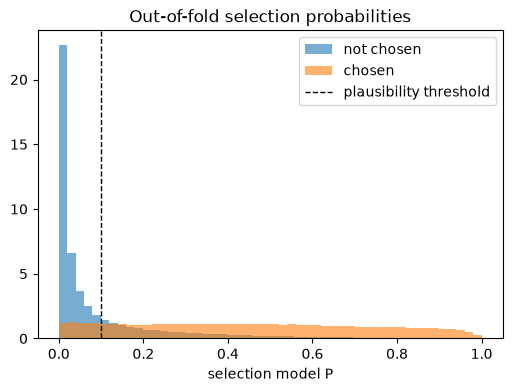

In [8]:
ap = opts[opts["is_actual"]]
rank = opts.groupby("event_id")["policy_p"].rank(ascending=False, method="average")
top1 = (rank[opts["is_actual"]] == 1).mean(); top3 = (rank[opts["is_actual"]] <= 3).mean()
print(f"mean P(actual) {ap['policy_p'].mean():.3f} vs uniform {(1 / dec['n_options']).mean():.3f}; top-1 {top1:.3f}, top-3 {top3:.3f}")
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(opts.loc[~opts["is_actual"], "policy_p"], bins=50, alpha=.6, density=True, label="not chosen")
ax.hist(ap["policy_p"], bins=50, alpha=.6, density=True, label="chosen")
ax.axvline(0.10, c="k", ls="--", lw=1, label="plausibility threshold"); ax.set(xlabel="selection model P", title="Out-of-fold selection probabilities"); ax.legend()
fig.savefig(OUT / "selection_probs.png", dpi=140, bbox_inches="tight")
for t in [0.05, 0.10, 0.20]:
    print(f"threshold {t:.2f}: median plausible options {opts.assign(pl=opts['policy_p'] >= t).groupby('event_id')['pl'].sum().median():.0f}")

## 5. Is decision quality a stable player trait?
Randomly split each player's matches into two halves and correlate per-player means across halves (Spearman,
players with ≥150 passes in both halves, averaged over 20 random splits). Metrics are made **team- and
role-relative** (limitation F: a Man City centre-back has different options than a relegation side's).

In [9]:
def pos_group(p):
    p = str(p)
    if "Goalkeeper" in p: return "GK"
    if "Back" in p: return "DEF"
    if "Defensive Midfield" in p or "Center Midfield" in p: return "CM/DM"
    return "ATT"
dec["pos_group"] = dec["position"].map(pos_group)
dec["neg_regret_poss"] = -dec["delta_ev_plausible_poss"]
for m in ["choice_pct_poss", "neg_regret_poss", "choice_pct_goal10", "completed"]:
    team_rel = dec[m] - dec.groupby(["team", "comp"])[m].transform("mean")
    dec[m + "_rel"] = team_rel - team_rel.groupby(dec["pos_group"]).transform("mean")

half_keys = dec[["player_id", "match_id"]].drop_duplicates()
def split_half(metric, min_passes=150, seeds=range(20)):
    rs = []
    for s in seeds:
        h = half_keys.assign(h=np.random.default_rng(s).integers(0, 2, len(half_keys)))
        agg = dec[["player_id", "match_id", metric]].merge(h, on=["player_id", "match_id"]).groupby(["player_id", "h"])[metric].agg(["mean", "size"]).unstack()
        agg = agg[(agg["size"] >= min_passes).all(axis=1)]
        rs.append(spearmanr(agg["mean"][0], agg["mean"][1]).statistic)
    return np.mean(rs), np.quantile(rs, [0.05, 0.95]), len(agg)
rows = []
for m in ["choice_pct_poss_rel", "neg_regret_poss_rel", "choice_pct_goal10_rel", "completed_rel"]:
    r, (lo, hi), n = split_half(m)
    rows.append({"metric (team- & role-relative)": m, "split-half Spearman": round(r, 3), "5-95% over splits": f"[{lo:.3f}, {hi:.3f}]", "players": n})
display(pd.DataFrame(rows).set_index("metric (team- & role-relative)"))

,split-half Spearman,5-95% over splits,players
metric (team- & role-relative),,,
choice_pct_poss_rel,0.193,"[0.066, 0.309]",87
neg_regret_poss_rel,0.489,"[0.391, 0.617]",87
choice_pct_goal10_rel,0.378,"[0.293, 0.448]",87
completed_rel,0.583,"[0.518, 0.641]",87


## 6. Leaderboard
Primary metric (pre-specified): **choice percentile under poss value, team- and role-relative**, in percentile
points. CIs are match-level cluster bootstraps. Outfield players with ≥500 scored passes.

In [10]:
metric = "choice_pct_poss_rel"
g = dec.groupby(["player_id", "player"])
lb = g.agg(passes=("event_id", "size"), matches=("match_id", "nunique"), team=("team", lambda s: s.mode().iloc[0]),
           role=("pos_group", lambda s: s.mode().iloc[0]), regret=("delta_ev_plausible_poss", "mean"),
           completion=("completed", "mean")).reset_index()
lb = lb[(lb["passes"] >= 500) & (lb["role"] != "GK")].copy()
cis = {pid: mean_ci(sub[metric].to_numpy(), sub["match_id"].to_numpy(), n_boot=300)
       for pid, sub in dec[dec["player_id"].isin(lb["player_id"])].groupby("player_id")}
lb["rel_pts"] = lb["player_id"].map(lambda p: cis[p][0] * 100).round(1)
lb["95% CI"] = lb["player_id"].map(lambda p: f"[{cis[p][1]*100:+.1f}, {cis[p][2]*100:+.1f}]")
lb["CI excludes 0"] = lb["player_id"].map(lambda p: cis[p][1] > 0 or cis[p][2] < 0)
cols = ["player", "team", "role", "passes", "matches", "rel_pts", "95% CI", "CI excludes 0", "regret", "completion"]
print(f"{len(lb)} players; {lb['CI excludes 0'].sum()} with CI excluding 0 (expected by chance at 5%: ~{0.05 * len(lb):.0f})")
display(Markdown("**Top 15**")); display(lb.sort_values("rel_pts", ascending=False)[cols].head(15).round(4).set_index("player"))
display(Markdown("**Bottom 10**")); display(lb.sort_values("rel_pts")[cols].head(10).round(4).set_index("player"))
lb.sort_values("rel_pts", ascending=False).to_csv(OUT / "decision_leaderboard.csv", index=False)

61 players; 15 with CI excluding 0 (expected by chance at 5%: ~3)


**Top 15**

,team,role,passes,matches,rel_pts,95% CI,CI excludes 0,regret,completion
player,,,,,,,,,
Irene Paredes Hernandez,Spain Women's,DEF,788,16,5.2,"[+1.3, +8.7]",True,0.0017,0.9708
Rodrigo Hernández Cascante,Spain,DEF,838,15,5.1,"[+2.6, +7.0]",True,0.0024,0.9869
Jonathan Tah,Bayer Leverkusen,DEF,1460,32,5.0,"[+3.5, +6.4]",True,0.0018,0.9884
Jeremie Frimpong,Bayer Leverkusen,DEF,500,29,4.7,"[+1.4, +7.4]",True,0.0038,0.8620
Declan Rice,England,CM/DM,731,19,2.7,"[+0.4, +5.3]",True,0.0023,0.9754
Renato Júnior Luz Sanches,Paris Saint-Germain,CM/DM,562,25,2.6,"[+0.3, +5.7]",True,0.0024,0.9626
John Stones,England,DEF,968,19,2.4,"[-0.7, +5.9]",False,0.0017,0.9876
Ángel Fabián Di María Hernández,Paris Saint-Germain,ATT,622,26,2.3,"[-0.3, +4.5]",False,0.0042,0.8826
Juan Bernat Velasco,Paris Saint-Germain,DEF,791,34,2.1,"[-0.5, +4.8]",False,0.0023,0.9545


**Bottom 10**

,team,role,passes,matches,rel_pts,95% CI,CI excludes 0,regret,completion
player,,,,,,,,,
Piero Martín Hincapié Reyna,Bayer Leverkusen,DEF,853,25,-5.2,"[-8.9, -1.1]",True,0.0019,0.9742
Clément Lenglet,Barcelona,DEF,1478,33,-3.6,"[-5.8, -1.8]",True,0.0019,0.9770
María Francesca Caldentey Oliver,Spain Women's,ATT,600,16,-3.2,"[-5.8, -0.9]",True,0.0037,0.9417
Kléper Laveran Lima Ferreira,Portugal,DEF,557,12,-3.1,"[-7.4, +0.8]",False,0.0016,0.9820
Pierre-Emile Højbjerg,Denmark,CM/DM,519,13,-2.8,"[-5.8, -0.1]",True,0.0033,0.9441
Sergino Dest,Barcelona,DEF,824,32,-2.5,"[-5.7, +0.2]",False,0.0029,0.9515
Aurélien Djani Tchouaméni,France,CM/DM,575,13,-2.4,"[-6.7, +1.8]",False,0.0025,0.9774
Sergio Ramos García,Paris Saint-Germain,DEF,1598,37,-2.4,"[-4.2, -0.3]",True,0.0020,0.9850
Granit Xhaka,Bayer Leverkusen,CM/DM,2436,43,-2.3,"[-3.7, -0.8]",True,0.0033,0.9659


## 7. The pass he didn't see: moments from finals
Largest poss-EV gaps to the best **plausible** option in the WC 2022 and Euro 2024 finals, for completed passes (so
we aren't just second-guessing turnovers). Gold ring size = option EV rank. Black = actual pass, gold = best
plausible option.

,comp,minute,team,player,recipient,actual_p_complete,ev_actual_poss,best_plausible_poss_p_complete,best_plausible_poss_policy_p,best_plausible_poss_ev,delta_ev_plausible_poss
126979,UEFA Euro 2024,12,Spain,Rodrigo Hernández Cascante,Robin Aime Robert Le Normand,0.2504,0.0409,0.3234,0.1158,0.1459,0.1049
34268,FIFA World Cup 2022,95,France,Kylian Mbappé Lottin,Randal Kolo Muani,0.8241,0.0470,0.7140,0.6466,0.1466,0.0996
127161,UEFA Euro 2024,46,Spain,Lamine Yamal Nasraoui Ebana,Nicholas Williams Arthuer,0.8516,0.0257,0.4884,0.2330,0.1006,0.0749
127289,UEFA Euro 2024,72,England,Jude Bellingham,Cole Palmer,0.9604,0.0272,0.3593,0.2938,0.0950,0.0678


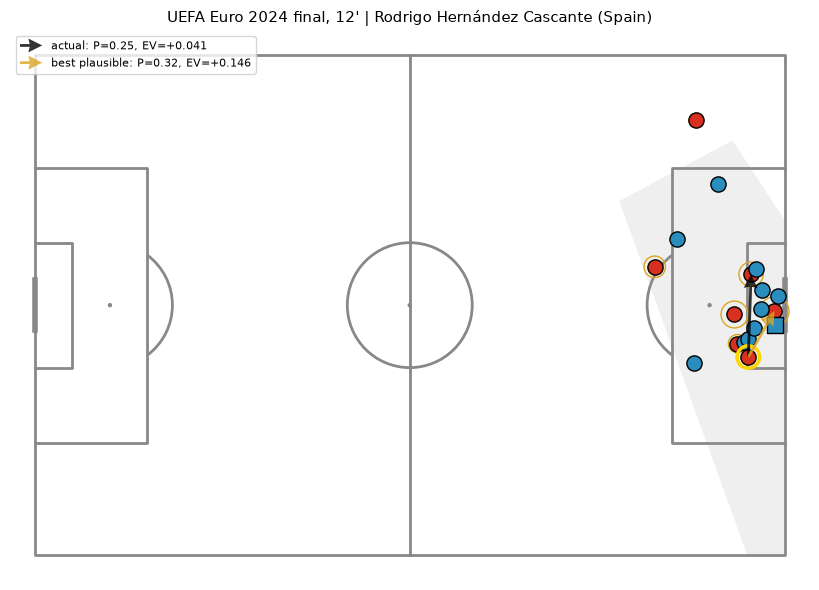

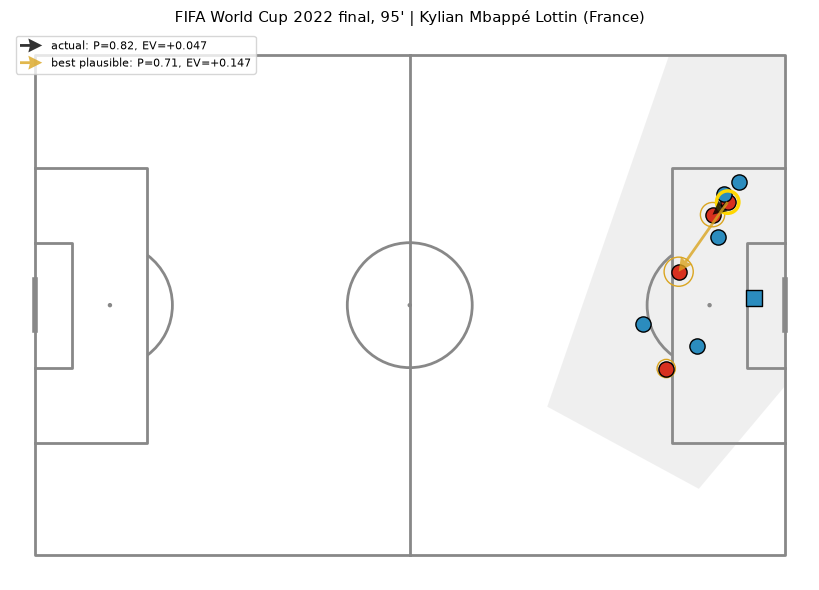

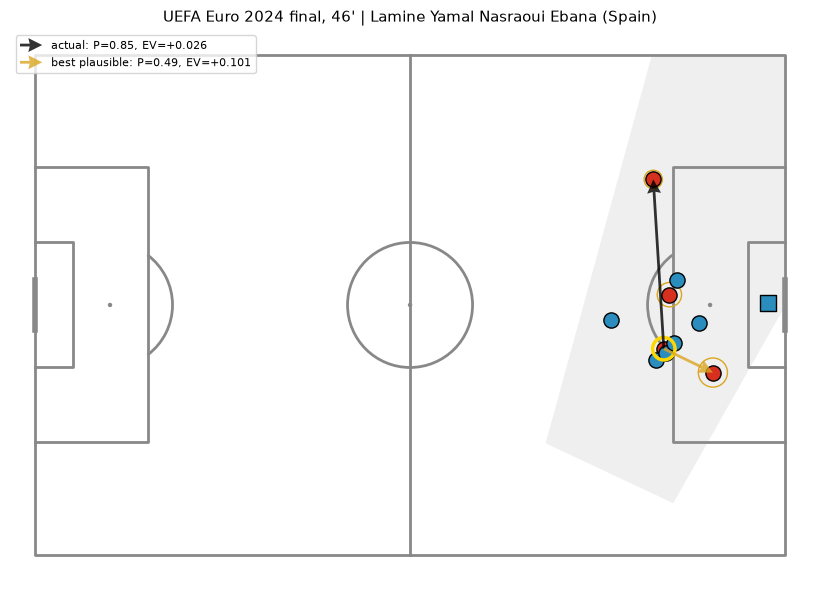

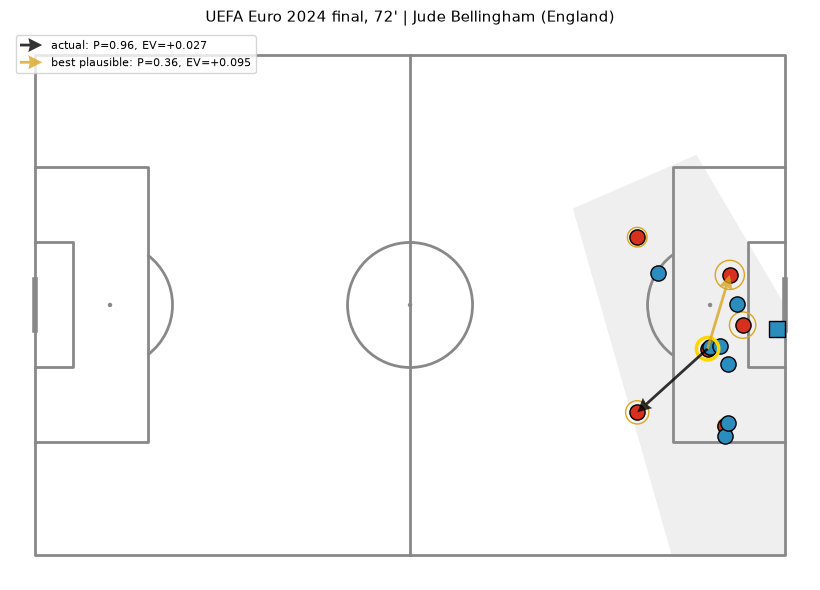

In [11]:
finals = matches[(matches["competition_stage_name"] == "Final") & matches["comp"].isin(["FIFA World Cup 2022", "UEFA Euro 2024"])]
cand = dec[dec["match_id"].isin(finals["match_id"]) & (dec["completed"] == 1) & (dec["n_plausible"] >= 2)]
cand = cand.sort_values("delta_ev_plausible_poss", ascending=False).head(4)
display(cand[["comp", "minute", "team", "player", "recipient", "actual_p_complete", "ev_actual_poss", "best_plausible_poss_p_complete",
              "best_plausible_poss_policy_p", "best_plausible_poss_ev", "delta_ev_plausible_poss"]].round(4))
ids = cand["event_id"].tolist()
players = load_table("players", filters=[("event_id", "in", ids)]); players["event_id"] = players["event_id"].astype(str)
frames = load_table("frames", columns=["event_id", "visible_area"], filters=[("event_id", "in", ids)]).set_index("event_id")
for _, r in cand.iterrows():
    o = opts[opts["event_id"] == r["event_id"]]
    ax = plot_freeze_frame(players[players["event_id"] == r["event_id"]], frames.loc[r["event_id"], "visible_area"], passes=[
        dict(start=(r["x"], r["y"]), end=(r["target_x"], r["target_y"]), color="k", label=f"actual: P={r['actual_p_complete']:.2f}, EV={r['ev_actual_poss']:+.3f}"),
        dict(start=(r["x"], r["y"]), end=(r["best_plausible_poss_opt_x"], r["best_plausible_poss_opt_y"]), color="goldenrod",
             label=f"best plausible: P={r['best_plausible_poss_p_complete']:.2f}, EV={r['best_plausible_poss_ev']:+.3f}")],
        title=f"{r['comp']} final, {r['minute']}' | {r['player']} ({r['team']})")
    ax.scatter(o["opt_x"], o["opt_y"], s=40 + 400 * o["ev_poss"].rank(pct=True), facecolors="none", edgecolors="goldenrod", lw=1, zorder=2)
    ax.figure.savefig(OUT / f"moment_{r['event_id'][:8]}.png", dpi=140, bbox_inches="tight")